## Objectives:
1. Load pretrained BERT model
2. Prompt finetune BERT model
3. Evaluate model performance on test data
4. Perform error analysis & adversarial testing

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, PromptTuningConfig, TaskType

Load the data

In [ ]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.head())

(34944, 2) (7464, 2) (7484, 2)
      label                                             review
0  positive  best cheap GPS: The Garmin Etrex, at under $10...
1  positive  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2  negative  So good we now buy Brother: Installing one of ...
3  positive  Powerful: Austin brings to life a part of the ...
4  positive  Tao terrific: This read is very informational ...


In [ ]:
# Convert string labels to binary labels
label_to_id_map = {"negative": 0, "positive": 1}
id_to_label_map = {0: "negative", 1: "positive"}
train_df["label"] = train_df["label"].map(label_to_id_map)
val_df["label"] = val_df["label"].map(label_to_id_map)
test_df["label"] = test_df["label"].map(label_to_id_map)
print(train_df.head())

   label                                             review
0      1  best cheap GPS: The Garmin Etrex, at under $10...
1      1  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2      0  So good we now buy Brother: Installing one of ...
3      1  Powerful: Austin brings to life a part of the ...
4      1  Tao terrific: This read is very informational ...


Load pretrained model and tokenizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Prompt tuning configuration
peft_config = PromptTuningConfig(
    task_type=TaskType.SEQ_CLS,
    num_virtual_tokens=20,       # Number of learnable virtual tokens
    prompt_tuning_init_text="Classify the sentiment of this text:"
)

# Apply to the model
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 16,898 || all params: 109,500,676 || trainable%: 0.0154


Tokenize text

In [ ]:
def tokenize_function(text):
    # Adjust max_length to account for the virtual tokens preprended to the prompt
    max_seq_length = tokenizer.model_max_length - peft_config.num_virtual_tokens
    return tokenizer(text["review"], padding="max_length", truncation=True, max_length=max_seq_length)

# Convert pandas DataFrames to Dataset objects
train_df = Dataset.from_pandas(train_df)
val_df = Dataset.from_pandas(val_df)
test_df = Dataset.from_pandas(test_df)

tokenized_train_df = train_df.map(tokenize_function, batched=True)
tokenized_val_df = val_df.map(tokenize_function, batched=True)
tokenized_test_df = test_df.map(tokenize_function, batched=True)

Map:   0%|          | 0/34944 [00:00<?, ? examples/s]

Map:   0%|          | 0/7464 [00:00<?, ? examples/s]

Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

Define metrics

In [ ]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

Train the model using the best hyperparameters

In [ ]:
model_name = "prompt-finetuned-bert-amazon-reviews"

# Define hyperaparamters
best_learning_rate = 2.3089e-5
best_batch_size = 32
best_weight_decay = 0.0074117

# Define training arguments
training_args = TrainingArguments(
    output_dir=model_name,
    eval_strategy="epoch",
    learning_rate=best_learning_rate,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    num_train_epochs=1,
    weight_decay=best_weight_decay,
    fp16=True,
    save_strategy="epoch",
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_train_df,
    eval_dataset=tokenized_val_df
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.690600,0.686568,0.564979,0.521728


TrainOutput(global_step=1092, training_loss=0.6922025645608867, metrics={'train_runtime': 703.1662, 'train_samples_per_second': 49.695, 'train_steps_per_second': 1.553, 'total_flos': 8835164779843584.0, 'train_loss': 0.6922025645608867, 'epoch': 1.0})

Evaluate the model

In [ ]:
# Evaluate on test data
preds_outputs = trainer.predict(tokenized_test_df)
preds_outputs.metrics

{'test_loss': 0.6861090660095215,
 'test_accuracy': 0.5704168893639765,
 'test_f1': 0.5316984187019276,
 'test_runtime': 72.3103,
 'test_samples_per_second': 103.498,
 'test_steps_per_second': 3.236}

              precision    recall  f1-score   support

    negative       0.64      0.28      0.39      3670
    positive       0.55      0.85      0.67      3814

    accuracy                           0.57      7484
   macro avg       0.60      0.56      0.53      7484
weighted avg       0.60      0.57      0.53      7484



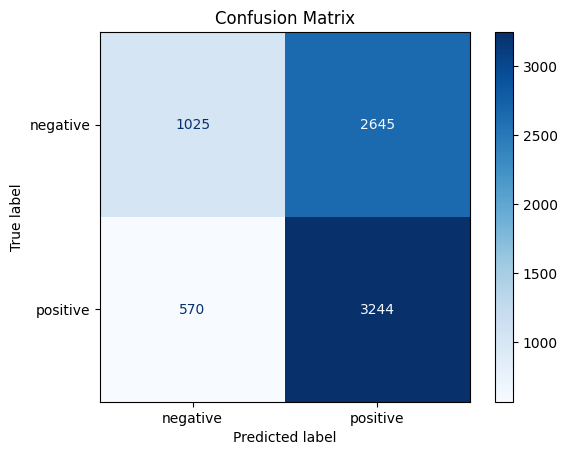

In [ ]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = [label for label in tokenized_test_df["label"]]
print(classification_report(y_true, y_preds, zero_division=0, target_names=id_to_label_map.values()))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Error analysis

In [ ]:
# Identify misclassified examples
misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_true, y_preds)) if true != pred]
misclassified_reviews = [test_df["review"][i] for i in misclassified_indices]
misclassified_true_labels = [id_to_label_map[y_true[i]] for i in misclassified_indices]
misclassified_predicted_labels = [id_to_label_map[y_preds[i]] for i in misclassified_indices]

# Display a few misclassified examples
print(f"Number of misclassified examples: {len(misclassified_indices)}")
print("\nSample misclassified examples:")
for i in range(min(5, len(misclassified_indices))):
    print(f"Review: {misclassified_reviews[i]}")
    print(f"True label: {misclassified_true_labels[i]}")
    print(f"Predicted label: {misclassified_predicted_labels[i]}")
    print("-" * 50)

Number of misclassified examples: 3215

Sample misclassified examples:
Review: Howlingly Horrible: This was one of the most embarassingly bad films I've seen in recent memory.I watched this because there is a 14 year old in the house who is understandably amused by girls in their early twenties dancing on top of a bar....and is willing to watch a non-plot for a half-hour between those scenes. Short of a pubescent male, I have to think that anyone who enjoyed this movie is either miguided (hopefully) or an idiot.If this is really what a person looks for in a film, let me recommend saving your money and watching nearly any television sit-com....they're just as bad and it won't cost you four bucks a pop. Take that extra four bucks and donate it to the library. That way, people who are dragging the human race intellectually down to such a depth can at least offset the damage they do by hopefully lifting someone else up.
True label: negative
Predicted label: positive
-----------------------

Adversarial testing

In [ ]:
# Test with adversarial examples, such as oxymorons, spelling errors, conflicting sentiments, sarcasm
adversarial_inputs = ["This movie was surprisingly not bad!",         # true label: positive
                      "This book is ecellent",                        # true label: positive
                      "This is good, but it is too expensive.",       # true label: negative
                      "The service was great... (not really)"]        # true label: negative

for text in adversarial_inputs:
    tokenized_inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs = {name: tensor.to(device) for name, tensor in tokenized_inputs.items()}

    outputs = model(**tokenized_inputs)
    predictions = torch.argmax(outputs.logits, axis=1)
    print(f"Adversarial prediction for '{text}': {id_to_label_map[predictions.item()]}")

Adversarial prediction for 'This movie was surprisingly not bad!': positive
Adversarial prediction for 'This book is ecellent': positive
Adversarial prediction for 'This is good, but it is too expensive.': positive
Adversarial prediction for 'The service was great... (not really)': negative


Save the model

In [ ]:
!pip install huggingface_hub --quiet

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# This will create a public repository under your username.
REPO_ID = "prompt-finetuned-bert-for-Amazon-sentiment-analysis"

# Push the model and tokenizer to the Hub
model.push_to_hub(REPO_ID, commit_message="Initial pretrained bert model")
tokenizer.push_to_hub(REPO_ID)